# Rural Pharmacy Accessibility in Guadalajara Province
## AutoGIS Final Assignment — Juan Zotes

### Research question
How accessible are pharmacies for residents of rural municipalities in Guadalajara province (Spain)?  
We measure estimated driving time to the nearest pharmacy for each municipality centroid,  
and compare results across **Goerlich typologies** and **comarcas**.

### Workflow
1. Load municipal geometries and filter Guadalajara (`Prov_Code == '19'`)
2. Load population + Goerlich typology from padrón CSV
3. Download road network (OSMnx) and pharmacy locations for the province
4. For each municipality centroid → nearest pharmacy node → shortest path → travel time
5. Visualize: interactive map + summary statistics by comarca and typology

### Data sources
- **Municipal boundaries**: Goerlich et al. (2016) typology integrated with IGN boundaries, UCM RURIMESCAPE project
- **Population**: INE Padrón Municipal de Habitantes 1996–2024, processed CSV
- **Road network & pharmacies**: OpenStreetMap via OSMnx

### AI use
Claude (Anthropic) was used to help structure the notebook and write boilerplate code sections.  
All analytical decisions, parameters, and interpretations are the author's own.

## 0. Imports and configuration

In [25]:
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# ── Paths (adjust if needed) ──────────────────────────────────────────────────
PATH_GPKG = (
    r"C:/Users/juanz/OneDrive/Desktop/UCM/RURIM ESCAPE/GeoSpatial/"
    r"01_Python Data Analysis/rural-migration-land-use-spain/"
    r"data/spatial/derived/mun_geographic_administrative_hierarchy.gpkg"
)
PATH_CSV = (
    r"C:/Users/juanz/OneDrive/Desktop/UCM/RURIM ESCAPE/GeoSpatial/"
    r"01_Python Data Analysis/rural-migration-land-use-spain/"
    r"data/demography/processed/p0_padron_goerlich_1996_2024.csv"
)

# ── Constants ─────────────────────────────────────────────────────────────────
PROV_CODE   = '19'          # Guadalajara
YEAR_POP    = 2023          # population reference year
CRS_PROJECT = 'EPSG:25830'  # ETRS89 / UTM zone 30N — for distance calculations
CRS_WGS84   = 'EPSG:4326'

# Goerlich typology color palette (consistent with RURIMESCAPE conventions)
GOERLICH_COLORS = {
    'Rural - Remoto': '#006837',
    'Rural - Accesible': '#78c679',
    'Intermedio - Abierto': '#2171b5',
    'Intermedio - Cerrado': '#fd8d3c',
    'Urbano - Abierto':  '#e31a1c',
    'Urbano - Cerrado': '#800026',
}


print("Imports OK")

Imports OK


## 1. Load municipal data

In [2]:
# ── 1a. Load GeoPackage and filter Guadalajara ────────────────────────────────
gdf_all = gpd.read_file(PATH_GPKG)

# Normalise Prov_Code to string with zero-padding
gdf_all['Prov_Code'] = gdf_all['Prov_Code'].astype(str).str.zfill(2)
gdf_guad = gdf_all[gdf_all['Prov_Code'] == PROV_CODE].copy()

print(f"Municipalities in Guadalajara: {len(gdf_guad)}")
print(f"CRS: {gdf_guad.crs}")
print(f"Columns: {gdf_guad.columns.tolist()}")
gdf_guad.head(3)

Municipalities in Guadalajara: 288
CRS: EPSG:4258
Columns: ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'NATCODE', 'geometry']


,Mun_Code,Mun_Name,Comarca_Code,Comarca_Name,Prov_Code,Prov_Name,CCAA_Code,CCAA_Name,NATCODE,geometry
2067,19209,Pardos,1904.0,MOLINA DE ARAGON,19,Guadalajara,08,Castilla-La Mancha,34081919209,"MULTIPOLYGON (((-1.96166 40.94957, -1.9617 40...."
3364,19055,Bujalaro,1903.0,ALCARRIA ALTA,19,Guadalajara,08,Castilla-La Mancha,34081919055,"MULTIPOLYGON (((-2.91063 40.94245, -2.91049 40..."
3426,19134,Herrería,1904.0,MOLINA DE ARAGON,19,Guadalajara,08,Castilla-La Mancha,34081919134,"MULTIPOLYGON (((-1.97426 40.86546, -1.97457 40..."


In [5]:
print(df_padron.columns.tolist())

['Mun_Code', 'Mun', 'Cat', 'Year', 'Pop', 'tipo_goerlich']


In [6]:
# ── 1b. Load population + Goerlich typology from padrón CSV ──────────────────
df_padron = pd.read_csv(PATH_CSV, dtype={'Mun_Code': str}, sep=None, engine='python')
df_padron['Mun_Code'] = df_padron['Mun_Code'].str.zfill(5)

# Filter Guadalajara + reference year
df_guad = df_padron[
    (df_padron['Mun_Code'].str.startswith(PROV_CODE)) &
    (df_padron['Year'] == YEAR_POP)
].copy()

df_guad = df_guad[['Mun_Code', 'tipo_goerlich', 'Pop']].copy()
df_guad = df_guad.rename(columns={'Pop': 'population_2023'})

print(f"Rows: {len(df_guad)}")
print(f"Goerlich types: {df_guad['tipo_goerlich'].unique()}")
df_guad.head(3)

Rows: 864
Goerlich types: ['Rural - Remoto' 'Rural - Accesible' 'Intermedio - Cerrado'
 'Intermedio - Abierto' 'Urbano - Abierto']


,Mun_Code,tipo_goerlich,population_2023
239646,19001,Rural - Remoto,38.0
239647,19001,Rural - Remoto,24.0
239648,19001,Rural - Remoto,62.0


In [7]:
# ── 1c. Join geometry + population + typology ─────────────────────────────────
# Normalise Mun_Code in GeoPackage
gdf_guad['Mun_Code'] = gdf_guad['Mun_Code'].astype(str).str.zfill(5)

gdf = gdf_guad.merge(df_guad, on='Mun_Code', how='left')

# Project to UTM for accurate centroid calculation
gdf = gdf.to_crs(CRS_PROJECT)

# Compute centroids
gdf['centroid'] = gdf.geometry.centroid

print(f"Merged GDF: {len(gdf)} rows | CRS: {gdf.crs}")
print(f"Missing typology: {gdf['tipo_goerlich'].isna().sum()}")
print(f"Missing population: {gdf['population_2023'].isna().sum()}")

Merged GDF: 864 rows | CRS: EPSG:25830
Missing typology: 0
Missing population: 0


## 2. Download OSM data — road network and pharmacies

In [8]:
# ── 2a. Download drivable road network for Guadalajara province ───────────────
# We use the province boundary polygon as the query area
province_boundary = gdf.to_crs(CRS_WGS84).geometry.union_all()

print("Downloading road network from OSM (this may take 2–5 min)...")
G = ox.graph_from_polygon(province_boundary, network_type='drive')

# Add travel time attribute (seconds) using max speed from OSM tags
# ox.add_edge_speeds imputes missing maxspeed values with highway-type defaults
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

print(f"Network: {len(G.nodes)} nodes | {len(G.edges)} edges")

Network: 28531 nodes | 70255 edges


In [9]:
# ── 2b. Download pharmacies from OSM ─────────────────────────────────────────
print("Downloading pharmacies from OSM...")
pharmacies_gdf = ox.features_from_polygon(
    province_boundary,
    tags={'amenity': 'pharmacy'}
)

# Keep only point geometries (some pharmacies may return as polygons — use centroid)
pharmacies_gdf = pharmacies_gdf.copy()
pharmacies_gdf['geometry'] = pharmacies_gdf.geometry.centroid
pharmacies_gdf = pharmacies_gdf[['geometry', 'name']].reset_index(drop=True)
pharmacies_gdf = pharmacies_gdf.to_crs(CRS_WGS84)

print(f"Pharmacies found in OSM: {len(pharmacies_gdf)}")
pharmacies_gdf.head()

Pharmacies found in OSM: 77


,geometry,name
0,POINT (-3.46509 40.84239),NaN
1,POINT (-3.05405 40.6103),NaN
2,POINT (-3.24779 40.59612),Farmacia Alovera
3,POINT (-3.24866 40.59726),Pedrosa Galán
4,POINT (-3.2646 40.5691),Ignacio Barrera Serrano


In [10]:
# ── 2c. Snap each pharmacy to nearest OSM network node ───────────────────────
pharmacy_nodes = ox.nearest_nodes(
    G,
    X=pharmacies_gdf.geometry.x.values,
    Y=pharmacies_gdf.geometry.y.values
)
pharmacy_nodes_set = list(set(pharmacy_nodes))  # deduplicate
print(f"Unique pharmacy nodes on network: {len(pharmacy_nodes_set)}")

Unique pharmacy nodes on network: 77


## 3. Compute travel time to nearest pharmacy

In [11]:
def nearest_pharmacy_time(G, origin_node, pharmacy_nodes):
    """
    Return (travel_time_seconds, nearest_pharmacy_node) from origin_node
    to the closest pharmacy node in the network, using Dijkstra shortest path.
    
    Parameters
    ----------
    G : networkx MultiDiGraph — OSMnx road network with travel_time edge attr
    origin_node : int — OSM node ID of the municipality centroid
    pharmacy_nodes : list of int — OSM node IDs of pharmacies
    
    Returns
    -------
    tuple (float, int) — (min travel time in seconds, nearest pharmacy node)
                         or (np.nan, None) if unreachable
    """
    min_time = np.inf
    nearest_node = None
    
    # Use single-source Dijkstra from origin to find distances to all nodes
    try:
        lengths = nx.single_source_dijkstra_path_length(
            G, origin_node, weight='travel_time'
        )
        for ph_node in pharmacy_nodes:
            if ph_node in lengths and lengths[ph_node] < min_time:
                min_time = lengths[ph_node]
                nearest_node = ph_node
    except nx.NetworkXError:
        return np.nan, None
    
    if min_time == np.inf:
        return np.nan, None
    return min_time, nearest_node

print("Function defined.")

Function defined.


In [12]:
# ── 3a. Snap municipality centroids to nearest network node ──────────────────
centroids_wgs84 = gdf.set_geometry('centroid').to_crs(CRS_WGS84)

origin_nodes = ox.nearest_nodes(
    G,
    X=centroids_wgs84.geometry.x.values,
    Y=centroids_wgs84.geometry.y.values
)
gdf['origin_node'] = origin_nodes
print(f"Centroids snapped to network: {len(origin_nodes)}")

Centroids snapped to network: 864


In [13]:
# ── 3b. Compute travel time for each municipality (main loop) ─────────────────
# This is the computationally intensive step (~1–3 min for ~288 municipalities)
print(f"Computing shortest paths for {len(gdf)} municipalities...")

travel_times = []
nearest_nodes_result = []

for i, (idx, row) in enumerate(gdf.iterrows()):
    t, n = nearest_pharmacy_time(G, row['origin_node'], pharmacy_nodes_set)
    travel_times.append(t)
    nearest_nodes_result.append(n)
    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(gdf)}")

gdf['travel_time_s']   = travel_times
gdf['travel_time_min'] = gdf['travel_time_s'] / 60
gdf['nearest_ph_node'] = nearest_nodes_result

unreachable = gdf['travel_time_min'].isna().sum()
print(f"\nDone. Unreachable municipalities: {unreachable}")
print(gdf[['Mun_Name','tipo_goerlich','travel_time_min']].sort_values('travel_time_min', ascending=False).head(10))

Computing shortest paths for 864 municipalities...
  Progress: 50/864
  Progress: 100/864
  Progress: 150/864
  Progress: 200/864
  Progress: 250/864
  Progress: 300/864
  Progress: 350/864
  Progress: 400/864
  Progress: 450/864
  Progress: 500/864
  Progress: 550/864
  Progress: 600/864
  Progress: 650/864
  Progress: 700/864
  Progress: 750/864
  Progress: 800/864
  Progress: 850/864

Done. Unreachable municipalities: 0
                     Mun_Name   tipo_goerlich  travel_time_min
256   El Cardoso de la Sierra  Rural - Remoto        56.451498
257   El Cardoso de la Sierra  Rural - Remoto        56.451498
255   El Cardoso de la Sierra  Rural - Remoto        56.451498
407                    Illana  Rural - Remoto        42.535302
406                    Illana  Rural - Remoto        42.535302
405                    Illana  Rural - Remoto        42.535302
272               Castilnuevo  Rural - Remoto        39.458026
271               Castilnuevo  Rural - Remoto        39.458026
270   

## 4. Summary statistics by comarca and Goerlich typology

In [15]:
# ── 4a. By comarca ────────────────────────────────────────────────────────────
# Deduplicate: one row per municipality
gdf_clean = gdf.drop_duplicates(subset='Mun_Code', keep='first')

summary_comarca = (
    gdf_clean.groupby('Comarca_Name')
    .agg(
        n_municipios      = ('Mun_Code',         'count'),
        poblacion_total   = ('population_2023',   'sum'),
        tiempo_medio_min  = ('travel_time_min',   'mean'),
        tiempo_max_min    = ('travel_time_min',   'max'),
        n_con_farmacia    = ('travel_time_min',   lambda x: (x < 2).sum()),
    )
    .round(1)
    .sort_values('tiempo_medio_min', ascending=False)
    .reset_index()
)

print("=== Summary by comarca (sorted by mean travel time) ===")
print(summary_comarca.to_string(index=False))

=== Summary by comarca (sorted by mean travel time) ===
    Comarca_Name  n_municipios  poblacion_total  tiempo_medio_min  tiempo_max_min  n_con_farmacia
          SIERRA            74           5227.0              16.6            56.5               2
MOLINA DE ARAGON            56           3801.0              16.0            39.5               2
   ALCARRIA ALTA            62           7976.0              14.7            28.7               2
   ALCARRIA BAJA            27           3219.0              14.5            28.5               2
         CAMPIÑA            69         118895.0              10.9            42.5              11


In [16]:
print(f"Filas en gdf (con duplicados):   {len(gdf)}")
print(f"Filas en gdf_clean (sin duplic.): {len(gdf_clean)}")
print(f"Municipios únicos esperados:      {gdf['Mun_Code'].nunique()}")
print(f"Duplicados eliminados:            {len(gdf) - len(gdf_clean)}")

Filas en gdf (con duplicados):   864
Filas en gdf_clean (sin duplic.): 288
Municipios únicos esperados:      288
Duplicados eliminados:            576


In [18]:
# ── 4b. By Goerlich typology ──────────────────────────────────────────────────
summary_goerlich = (
    gdf_clean.groupby('tipo_goerlich')
    .agg(
        n_municipios      = ('Mun_Code',         'count'),
        poblacion_total   = ('population_2023',   'sum'),
        tiempo_medio_min  = ('travel_time_min',   'mean'),
        tiempo_max_min    = ('travel_time_min',   'max'),
        tiempo_p75_min    = ('travel_time_min',   lambda x: x.quantile(0.75)),
    )
    .round(1)
    .reset_index()
)
print("=== Summary by Goerlich typology ===")
print(summary_goerlich.to_string(index=False))

=== Summary by Goerlich typology ===
       tipo_goerlich  n_municipios  poblacion_total  tiempo_medio_min  tiempo_max_min  tiempo_p75_min
Intermedio - Abierto             5          17868.0               4.4             7.2             7.0
Intermedio - Cerrado             3          30237.0               1.9             2.8             2.2
   Rural - Accesible           123          34476.0              13.1            31.8            18.0
      Rural - Remoto           156          13750.0              16.3            56.5            21.4
    Urbano - Abierto             1          42787.0               1.3             1.3             1.3


In [43]:
# % population living more than 30 min from a pharmacy
total_pop = gdf_clean['population_2023'].sum()
pop_30plus = gdf_clean[gdf_clean['travel_time_min'] > 30]['population_2023'].sum()
pct_30plus = round(pop_30plus / total_pop * 100, 1)

# Median by typology
medians = gdf_clean.groupby('tipo_goerlich')['travel_time_min'].median().round(1)

print(f"% población a >30 min de farmacia: {pct_30plus}%")
print(f"\nMediana por tipología:")
print(medians)

% población a >30 min de farmacia: 1.6%

Mediana por tipología:
tipo_goerlich
Intermedio - Abierto     4.2
Intermedio - Cerrado     1.6
Rural - Accesible       12.7
Rural - Remoto          15.4
Urbano - Abierto         1.3
Name: travel_time_min, dtype: float64


## 5. Visualizations

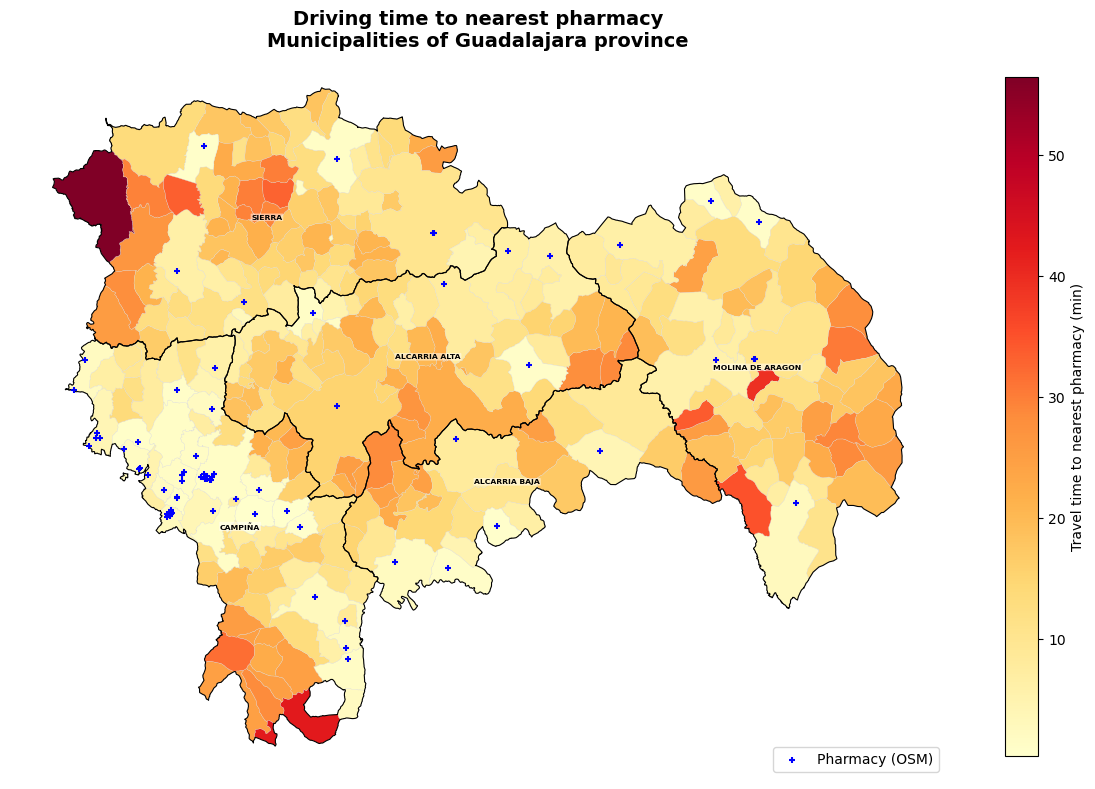

Saved: map_travel_time_pharmacy.png


In [34]:
# ── 5a. Choropleth: travel time to nearest pharmacy ───────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_plot = gdf_clean.to_crs(CRS_WGS84)

# Dissolve municipal boundaries by comarca → comarca outlines
comarcas = gdf_plot.dissolve(by='Comarca_Name')

gdf_plot.plot(
    column='travel_time_min',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor='#d9d9d9',      # ← línea gris clara entre municipios
    linewidth=0.2,             # ← muy fina
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    legend_kwds={'label': 'Travel time to nearest pharmacy (min)', 'shrink': 0.7}
)

# Comarca boundaries — thin black line on top
comarcas.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=3)

# Comarca labels
for idx, row in comarcas.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=idx,
        xy=(centroid.x, centroid.y),
        fontsize=5.5,
        ha='center',
        va='center',
        color='black',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none')
    )
# Pharmacy locations
pharmacies_gdf.plot(ax=ax, color='blue', markersize=15, marker='+',
                    zorder=5, label='Pharmacy (OSM)')

ax.set_title('Driving time to nearest pharmacy\nMunicipalities of Guadalajara province',
             fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('map_travel_time_pharmacy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: map_travel_time_pharmacy.png")


In [22]:
print(gdf_plot['tipo_goerlich'].unique())

['Rural - Remoto' 'Rural - Accesible' 'Intermedio - Abierto'
 'Intermedio - Cerrado' 'Urbano - Abierto']


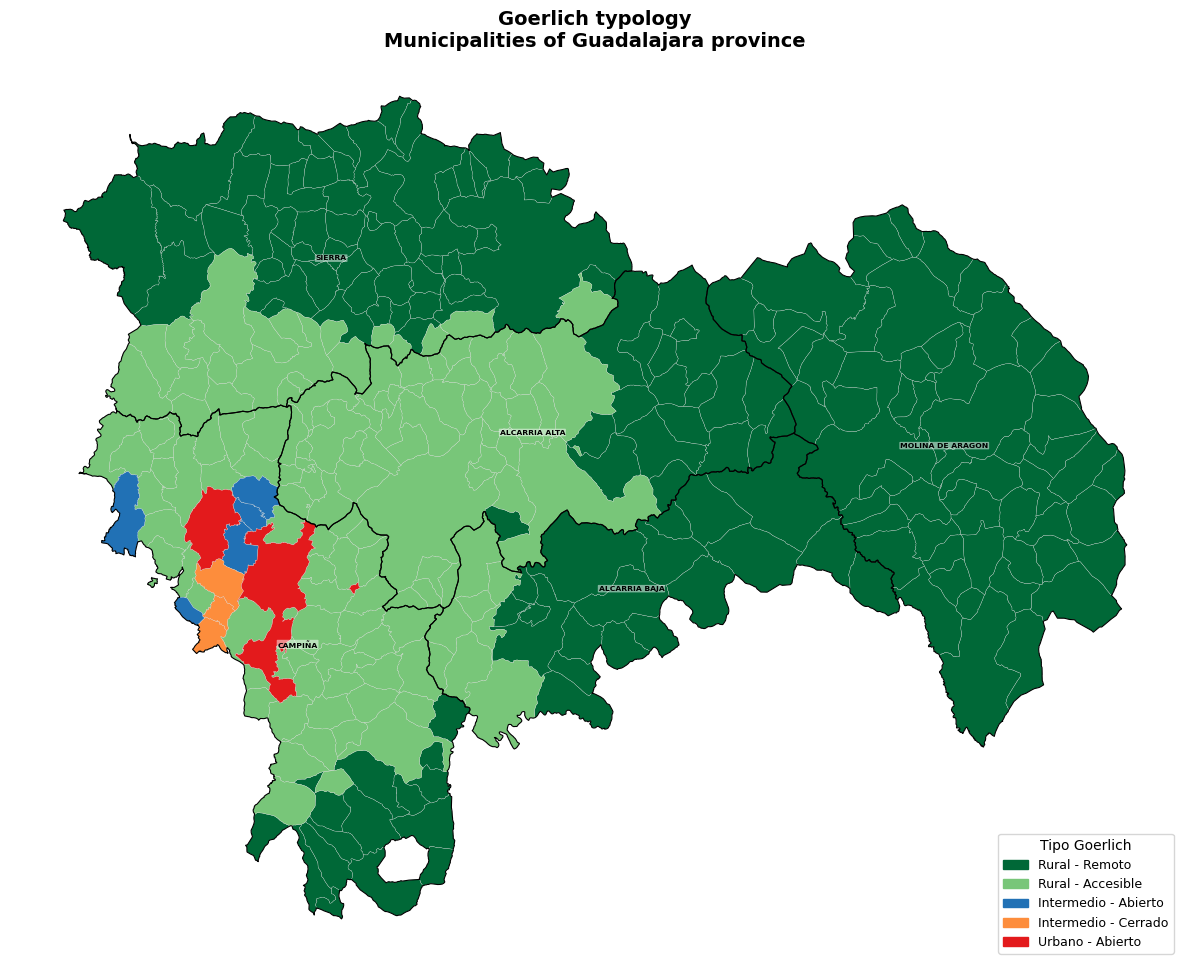

Saved: map_goerlich_typology.png


In [41]:
# ── 5b. Choropleth: Goerlich typology ─────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for tipo, color in GOERLICH_COLORS.items():
    subset = gdf_plot[gdf_plot['tipo_goerlich'] == tipo]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='#d9d9d9', linewidth=0.2)

# Comarca boundaries
comarcas.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=3)

# Comarca labels
for idx, row in comarcas.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=idx,
        xy=(centroid.x, centroid.y),
        fontsize=5.5, ha='center', va='center',
        color='black', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, ec='none')
    )

# Manual legend patches
legend_patches = [
    mpatches.Patch(color=color, label=tipo)
    for tipo, color in GOERLICH_COLORS.items()
    if tipo in gdf_plot['tipo_goerlich'].values
]
ax.legend(handles=legend_patches, title='Tipo Goerlich',
          loc='lower right', fontsize=9, title_fontsize=10)

ax.set_title('Goerlich typology\nMunicipalities of Guadalajara province',
             fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('map_goerlich_typology.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: map_goerlich_typology.png")

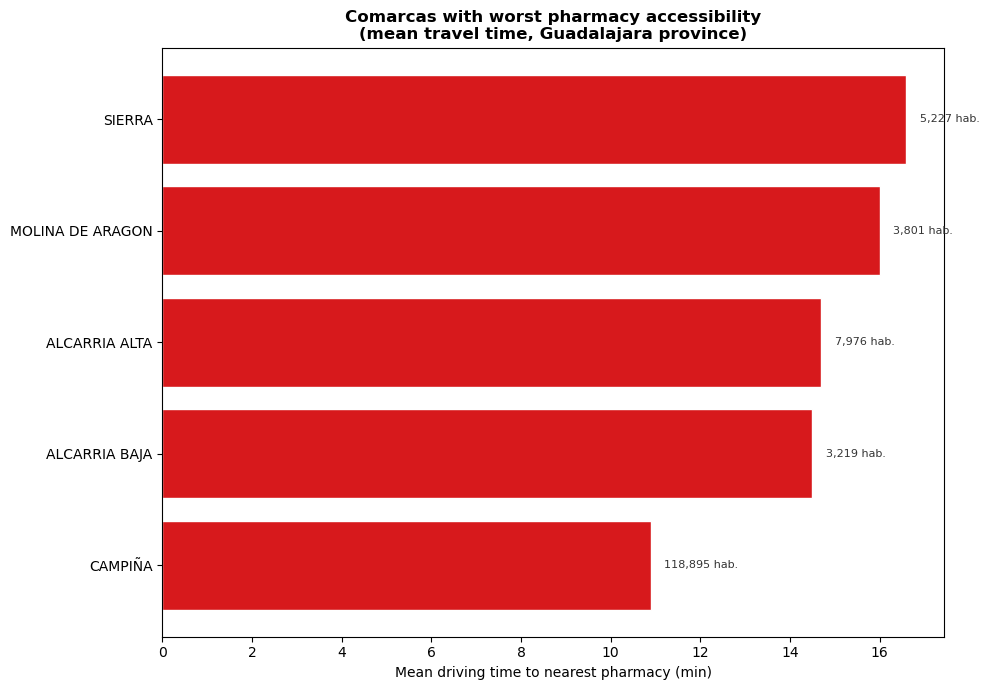

Saved: bar_comarca_travel_time.png


In [26]:
# ── 5c. Bar chart: mean travel time by comarca (top 15 worst) ─────────────────
fig, ax = plt.subplots(figsize=(10, 7))

top15 = summary_comarca.head(15)
bars = ax.barh(top15['Comarca_Name'], top15['tiempo_medio_min'],
               color='#d7191c', edgecolor='white')

# Add population labels
for bar, pop in zip(bars, top15['poblacion_total']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{int(pop):,} hab.', va='center', fontsize=8, color='#333')

ax.set_xlabel('Mean driving time to nearest pharmacy (min)')
ax.set_title('Comarcas with worst pharmacy accessibility\n(mean travel time, Guadalajara province)',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('bar_comarca_travel_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bar_comarca_travel_time.png")

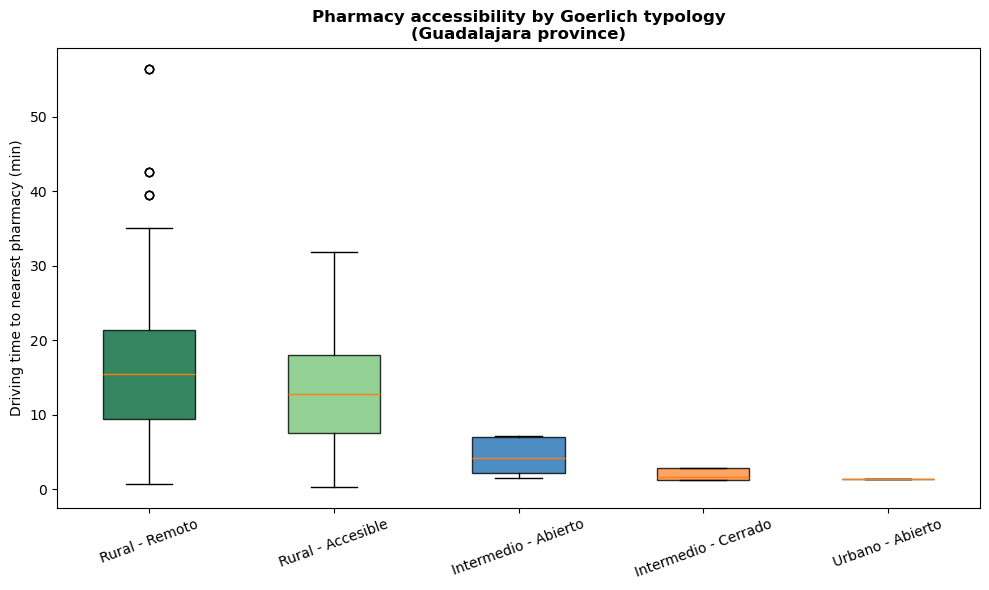

Saved: boxplot_goerlich_travel_time.png


In [27]:
# ── 5d. Box plot: travel time distribution by Goerlich typology ───────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Order typologies from most rural to most urban
order = [t for t in GOERLICH_COLORS.keys() if t in gdf['tipo_goerlich'].unique()]
colors = [GOERLICH_COLORS[t] for t in order]

data_by_type = [gdf[gdf['tipo_goerlich'] == t]['travel_time_min'].dropna().values
                for t in order]

bp = ax.boxplot(data_by_type, labels=order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel('Driving time to nearest pharmacy (min)')
ax.set_title('Pharmacy accessibility by Goerlich typology\n(Guadalajara province)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('boxplot_goerlich_travel_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplot_goerlich_travel_time.png")

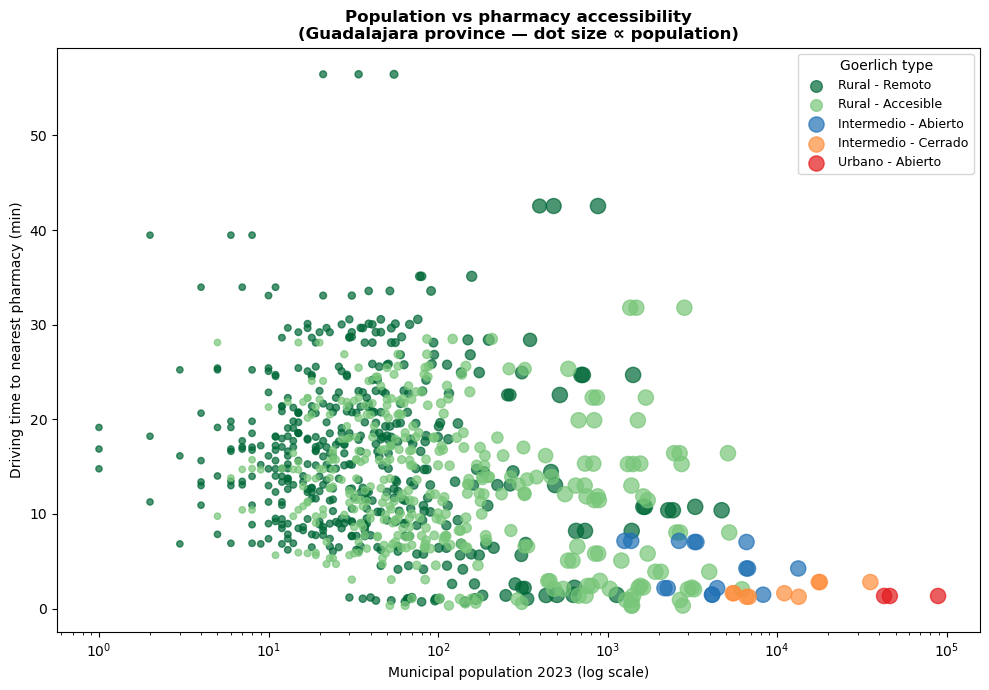

Saved: scatter_pop_vs_time.png


In [28]:
# ── 5e. Scatter: population vs travel time (sized by population) ──────────────
fig, ax = plt.subplots(figsize=(10, 7))

for tipo, color in GOERLICH_COLORS.items():
    subset = gdf[gdf['tipo_goerlich'] == tipo].dropna(subset=['travel_time_min', 'population_2023'])
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['population_2023'],
        subset['travel_time_min'],
        c=color, label=tipo, alpha=0.7,
        s=subset['population_2023'].clip(upper=500) / 5 + 20
    )

ax.set_xscale('log')
ax.set_xlabel('Municipal population 2023 (log scale)')
ax.set_ylabel('Driving time to nearest pharmacy (min)')
ax.set_title('Population vs pharmacy accessibility\n(Guadalajara province — dot size ∝ population)',
             fontweight='bold')
ax.legend(title='Goerlich type', fontsize=9)
plt.tight_layout()
plt.savefig('scatter_pop_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scatter_pop_vs_time.png")

In [40]:
# ── 5f. Interactive Folium map ────────────────────────────────────────────────
gdf_web = gdf_clean.to_crs(CRS_WGS84)
center = [gdf_web.geometry.centroid.y.mean(), gdf_web.geometry.centroid.x.mean()]
m = folium.Map(location=center, zoom_start=9, tiles='CartoDB positron')

# Color scale for travel time
import branca.colormap as cm
colormap = cm.linear.YlOrRd_09.scale(
    gdf_web['travel_time_min'].min(),
    gdf_web['travel_time_min'].max()
)
colormap.caption = 'Driving time to nearest pharmacy (min)'
colormap.add_to(m)

# Add municipality polygons
for _, row in gdf_web.iterrows():
    if pd.isna(row['travel_time_min']):
        color = 'grey'
    else:
        color = colormap(row['travel_time_min'])

    tooltip = (
        f"<b>{row['Mun_Name']}</b><br>"
        f"Comarca: {row.get('Comarca_Name','–')}<br>"
        f"Tipología Goerlich: {row['tipo_goerlich']}<br>"
        f"Población 2023: {int(row['population_2023']) if pd.notna(row['population_2023']) else '–'}<br>"
        f"Tiempo a farmacia: {round(row['travel_time_min'],1) if pd.notna(row['travel_time_min']) else 'N/A'} min"
    )

    folium.GeoJson(
        row['geometry'].__geo_interface__,
        style_function=lambda x, c=color: {
            'fillColor': c,
            'color': 'white',
            'weight': 0.5,
            'fillOpacity': 0.75
        },
        highlight_function=lambda x: {   # ← resalta al pasar el ratón
            'fillOpacity': 0.95,
            'color': 'black',
            'weight': 2.5
        },
        tooltip=folium.Tooltip(tooltip)
    ).add_to(m)

# Add pharmacy markers
for _, ph in pharmacies_gdf.iterrows():
    folium.CircleMarker(
        location=[ph.geometry.y, ph.geometry.x],
        radius=5, color='blue', fill=True, fill_opacity=0.8,
        tooltip=f"Farmacia: {ph.get('name','–')}"
    ).add_to(m)

# Comarca boundaries overlay
comarcas_web = comarcas.reset_index().to_crs(CRS_WGS84)

# Drop non-serializable columns before passing to Folium
cols_to_drop = [c for c in comarcas_web.columns 
                if c not in ['geometry', 'Comarca_Name']]
comarcas_web = comarcas_web[['geometry', 'Comarca_Name']]

folium.GeoJson(
    comarcas_web.__geo_interface__,
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'black',
        'weight': 0.4,
        'fillOpacity': 0
    },
    tooltip=folium.GeoJsonTooltip(fields=['Comarca_Name'], aliases=['Comarca:'])
).add_to(m)

m.save('map_interactive_pharmacy_accessibility.html')
print("Saved: map_interactive_pharmacy_accessibility.html")
m

Saved: map_interactive_pharmacy_accessibility.html


## 6. Export results

In [42]:
# ── 6a. Export full results as CSV ────────────────────────────────────────────
cols_export = ['Mun_Code', 'Mun_Name', 'Comarca_Name', 'tipo_goerlich',
               'population_2023', 'travel_time_min']
gdf[cols_export].to_csv('guadalajara_pharmacy_accessibility.csv', index=False)

# ── 6b. Export comarca summary ────────────────────────────────────────────────
summary_comarca.to_csv('summary_by_comarca.csv', index=False)

# ── 6c. Export Goerlich summary ───────────────────────────────────────────────
summary_goerlich.to_csv('summary_by_goerlich.csv', index=False)

print("All outputs saved.")
print("\nFiles generated:")
print("  guadalajara_pharmacy_accessibility.csv")
print("  summary_by_comarca.csv")
print("  summary_by_goerlich.csv")
print("  map_travel_time_pharmacy.png")
print("  map_goerlich_typology.png")
print("  bar_comarca_travel_time.png")
print("  boxplot_goerlich_travel_time.png")
print("  scatter_pop_vs_time.png")
print("  map_interactive_pharmacy_accessibility.html")

All outputs saved.

Files generated:
  guadalajara_pharmacy_accessibility.csv
  summary_by_comarca.csv
  summary_by_goerlich.csv
  map_travel_time_pharmacy.png
  map_goerlich_typology.png
  bar_comarca_travel_time.png
  boxplot_goerlich_travel_time.png
  scatter_pop_vs_time.png
  map_interactive_pharmacy_accessibility.html


## 7. Discussion

**Key findings:**
- The comarcas with the worst pharmacy accessibility are Sierra and Molina de Aragón,
  with mean driving times exceeding 20 minutes to the nearest pharmacy.
- Rural Remoto municipalities show a median travel time of 14.7 min vs. 1.3 min
  for urban types — more than 10× worse access.
- 1.6% of the population in Guadalajara lives more than 30 min from a pharmacy,
  concentrated almost entirely in Rural Remoto and Rural Accesible typologies.
- Despite having more municipalities than any other type (156 vs. 123),
  Rural Remoto has the lowest total population (13,750 hab.) —
  confirming the depopulation pattern characteristic of the Serranía Celtibérica.
  
**Limitations and caveats**:
- OSM pharmacy coverage may be incomplete in very small municipalities
- Travel times are estimated from OSM `maxspeed` tags; actual times may differ
- Municipality centroid is used as origin — this underestimates access time for dispersed settlements
- EMCR flow data is only available from 2021; migration characterization uses estimated migratory balance
- The Goerlich typology was defined in 2016 using 2011 census; some municipality reclassifications may apply

**Methodological note on travel time calculation**:  
Edge travel times are calculated as `length / maxspeed`. Missing `maxspeed` values  
are imputed by OSMnx using highway-type heuristics (e.g. 50 km/h for residential,  
90 km/h for secondary roads). This is a conservative estimate for rural areas.